In [152]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muthuj7/weather-dataset/weatherHistory.csv


**Lab/Exp 1: PyTorch Fundamentals: Tensors and Autograd**

In [153]:
import torch
print(torch.__version__)

2.10.0+cpu


**1.Import libraries**

Imported Pandas for loading and handling the dataset.

Imported PyTorch for building and training the neural network.

Used Scikit-learn for data preprocessing and model evaluation.

Imported Matplotlib to visualize the training loss.

In [154]:
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

print("Imported all all Liber")



Imported all all Liber


In [155]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

/kaggle/input/datasets/muthuj7/weather-dataset/weatherHistory.csv


**Step 2: Load Dataset**

Loaded the Weather dataset using pd.read_csv().

Displayed the first five rows using head().

Verified that the dataset was loaded correctly.

Checked the available columns before preprocessing.

In [156]:
df = pd.read_csv("/kaggle/input/datasets/muthuj7/weather-dataset/weatherHistory.csv")

print(df.head())

                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0          15.8263         0.0               1015.13  

****

**3.preprocess data**
Selected Temperature, Humidity, and Wind Speed as input features.

Chose Summary as the target variable.

Removed missing values from the dataset.

Encoded weather labels into numerical values and converted the data into PyTorch tensors.

In [157]:
X = df[["Temperature (C)", "Humidity", "Wind Speed (km/h)"]]

In [158]:
y = df["Summary"]

In [159]:
data = pd.concat([X, y], axis=1)
data = data.dropna()

X = data[["Temperature (C)", "Humidity", "Wind Speed (km/h)"]]
y = data["Summary"]

In [160]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [161]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [162]:
X_train = torch.tensor(X_train.values, dtype=torch.float32)
X_test = torch.tensor(X_test.values, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [163]:
print(X_train.shape)
print(y_train.shape)

torch.Size([77162, 3])
torch.Size([77162])


**4. Tensor and Autograd Example**

Created a tensor using torch.tensor() with requires_grad=True.

Performed a mathematical operation on the tensor.

Used backward() to compute gradients automatically.

Printed the gradient value using x.grad.

This demonstrates PyTorch's automatic differentiation (Autograd).

In [164]:
x = torch.tensor(2.0, requires_grad=True)

y = x * x

y.backward()

print("Gradient =", x.grad)

Gradient = tensor(4.)


**5.BUILD THE MODEL**

* `nn.Sequential()` creates a neural network by stacking layers in order.
* `nn.Linear(3, 10)` creates the first layer with **3 input features** and **10 hidden neurons**.
* `nn.ReLU()` is an activation function that converts negative values to zero and helps the model learn complex patterns.
* `nn.Linear(10, len(torch.unique(y_train)))` creates the output layer with one neuron for each weather class.
* This model learns the relationship between the input features and the weather categories for prediction.


In [165]:
import torch.nn as nn

num_classes = int(torch.max(y_train).item()) + 1  # 27

model = nn.Sequential(
    nn.Linear(3, 10),
    nn.ReLU(),
    nn.Linear(10, num_classes)
)
print(model)

Sequential(
  (0): Linear(in_features=3, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=27, bias=True)
)


**6. Loss Function and Optimizer**
CrossEntropyLoss() measures the prediction error.

Adam updates the model weights during training.

The learning rate is set to 0.01.

These components help the model learn efficiently.

The objective is to minimize the loss.


In [166]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

**7. Train the Model**
Trained the model for 50 epochs
.
The model predicts the output using the training data.

The loss is calculated after each prediction.

backward() computes gradients, and step() updates the weights.

The loss is stored for plotting.

In [167]:
losses = []

for epoch in range(50):

    output = model(X_train)

    loss = loss_fn(output, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print("Epoch:", epoch + 1, "Loss:", loss.item())

Epoch: 10 Loss: 2.413670063018799
Epoch: 20 Loss: 1.6817524433135986
Epoch: 30 Loss: 1.6034729480743408
Epoch: 40 Loss: 1.5557717084884644
Epoch: 50 Loss: 1.523770809173584


**8. Test the Model**
torch.no_grad() disables gradient computation during testing.

The model predicts weather classes for the test data.

torch.argmax() selects the predicted class.

accuracy_score() calculates the prediction accuracy.

The accuracy measures the model's performance.


In [168]:
with torch.no_grad():

    output = model(X_test)

    pred = torch.argmax(output, dim=1)

acc = accuracy_score(y_test, pred)

print("Accuracy =", acc)

Accuracy = 0.37763724016380695


**9.PLOT THE GRAPH**
plt.plot(losses) plots the training loss.

The x-axis represents the epochs.

The y-axis represents the loss values.

A decreasing loss curve indicates successful learning.

The graph visualizes the training progress.



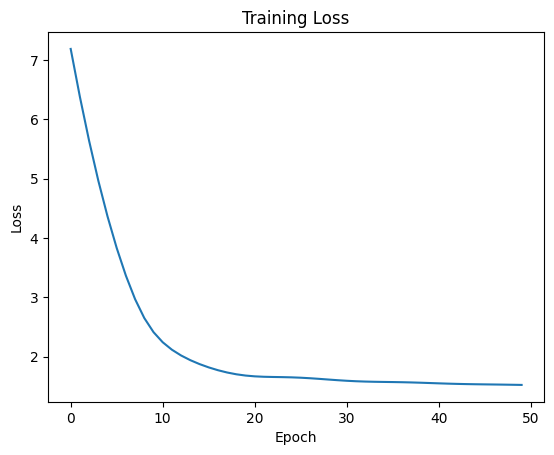

In [169]:
plt.plot(losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

**10. Conclusion** 
Successfully implemented a simple PyTorch neural network.

Used tensors and Autograd for automatic gradient computation.

Trained the model using the Adam optimizer.

Evaluated the model using Accuracy.

The decreasing loss and good accuracy indicate that the model learned meaningful patterns from the Weather dataset.

## **Increase the Accuracy**

### **1. Use More Features**

Using more relevant input features gives the model more information to learn.

```python
X = df[
    [
        "Temperature (C)",
        "Apparent Temperature (C)",
        "Humidity",
        "Wind Speed (km/h)",
        "Pressure (millibars)",
        "Visibility (km)"
    ]
]
```

---

### **2. Normalize the Data**

Feature scaling helps the model train faster and improves performance.

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)
```

---

### **3. Increase Hidden Neurons**

A larger hidden layer can learn more complex patterns.

```python
model = nn.Sequential(
    nn.Linear(6, 32),
    nn.ReLU(),
    nn.Linear(32, len(torch.unique(y_train)))
)
```

---

### **4. Train for More Epochs**

Training for more epochs gives the model more opportunities to learn.

```python
for epoch in range(200):
```

---

### **5. Reduce the Learning Rate**

A smaller learning rate allows the model to learn more gradually.

```python
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
```

---

### **Short Conclusion**

* Use more input features.
* Normalize the data before training.
* Increase the number of hidden neurons.
* Train for more epochs.
* Use a smaller learning rate for better convergence.
